In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pyvista as pv
import nest_asyncio

nest_asyncio.apply()

pv.set_jupyter_backend('trame')

from pyvista.trame.jupyter import launch_server
await launch_server().ready

from Suspension.hardpoint_loader import load_suspension_params
from Suspension.jax_solvers import solve_and_measure_corner
from Suspension.visualizer import SuspensionVisualizer
from Suspension.jax_solvers import get_world_params
from Suspension.jax_solvers import solve_theta_for_ground

In [2]:
'''SINGLE POINT TEST BLOCK'''

corner_name = "front_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

def report_caster(upper_bj: jnp.array, lower_bj: jnp.array):
    """Find caster angle given balljoint positions (XZ Plane)"""
    
    # Vector pointing from Lower BJ to Upper BJ
    bj_vec = upper_bj - lower_bj
    
    # In the XZ plane:
    # dx is the longitudinal lean (Forward/Rearward)
    # dz is the vertical height
    dx = bj_vec[0]
    dz = bj_vec[2]
    
    # atan2(forward, vertical) gives the angle from the vertical axis
    # We negate it depending on your convention (usually rearward lean is positive)
    caster_rad = jnp.atan2(-dx, dz) 
    
    return caster_rad

metrics = solve_and_measure_corner(0.0, 0.0, params)

print(metrics['lower_bj'])
print(metrics['upper_bj'])
print(metrics['caster'])
print(metrics['instant_roll_center'])
print(metrics['contact_point'][2])
# print(metrics['instant_pitch_center'])

[ 1.5367     -0.5629      0.13380006]
[ 1.511  -0.5332  0.3213]
0.13621774
[1.5367001  6.916096   0.19064187]
0.00023590028


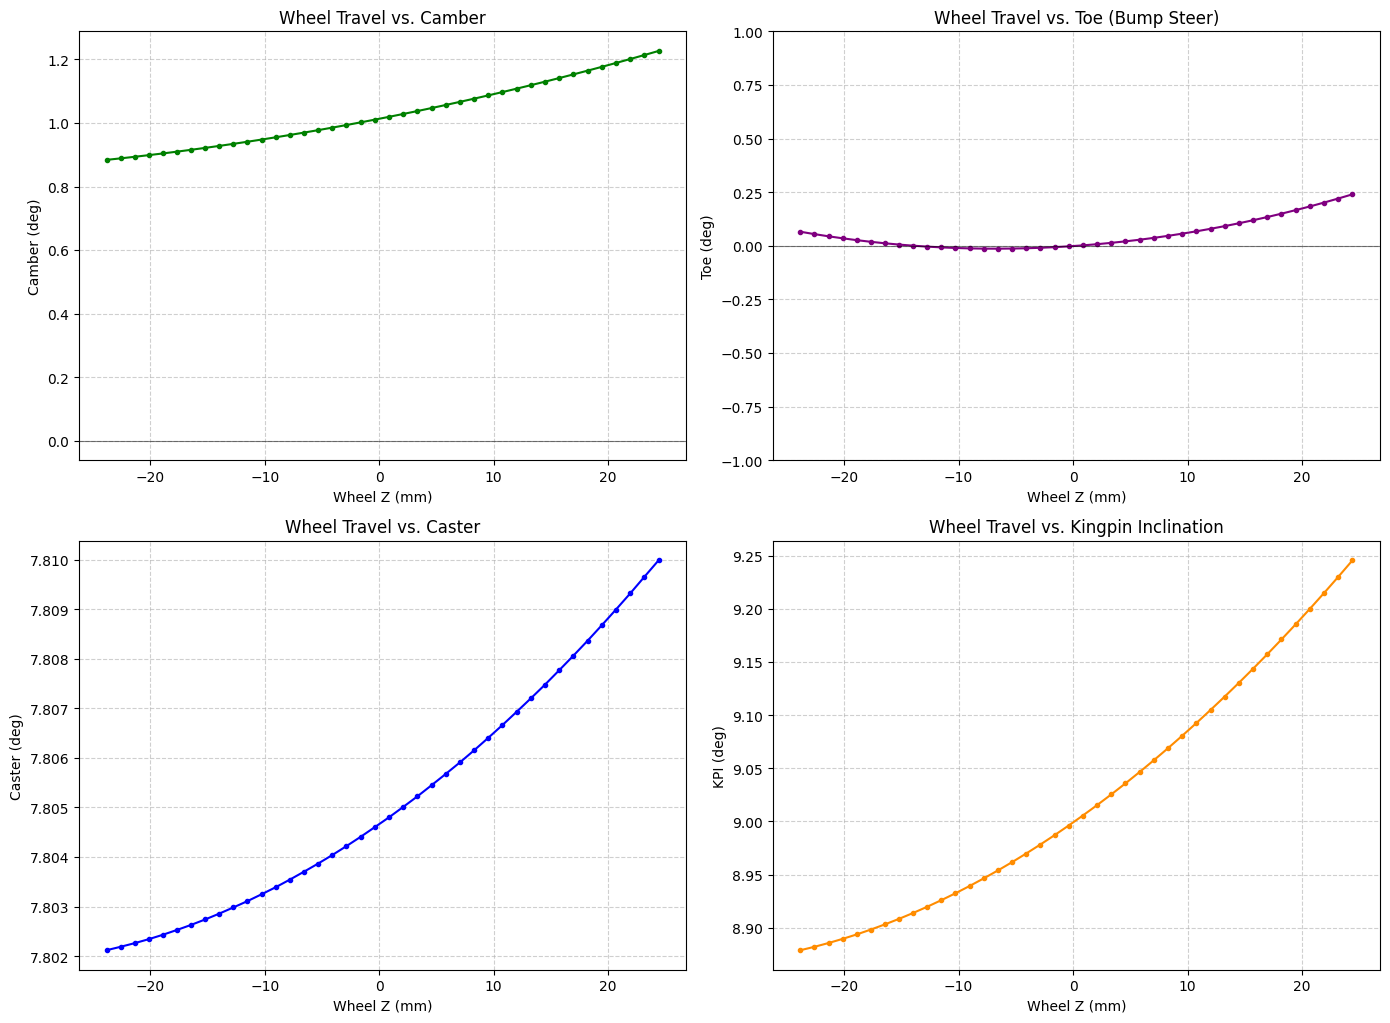

In [3]:
'''SWEEP TEST BLOCK'''

# 1. Setup Parameters
corner_name = "front_left"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Define the Range of Motion
thetas = jnp.radians(jnp.linspace(-5.0, 5.0, 40)) 
# thetas = 0.0
fixed_steer = 0.0

# 3. Initialize storage for results
travel_mm = []
caster_deg = []
scrub_mm = []
camber_deg = []
toe_deg = []
kpi_deg = []    
mech_trail_mm = [] 
contact_point = []

# 4. Run the Sweep Loop
for t in thetas:
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Store the values (converting to readable units)
    travel_mm.append(metrics["wheel_z"] * 1000)
    caster_deg.append(jnp.degrees(metrics["caster"]))
    scrub_mm.append(metrics["scrub_radius"] * 1000)
    camber_deg.append(jnp.degrees(metrics["camber"]))
    toe_deg.append(jnp.degrees(metrics["toe"]))
    kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
    mech_trail_mm.append(metrics["mechanical_trail"] * 1000)
    contact_point.append(metrics["contact_point"][2]*1000)

    # print(metrics["contact_point"][2])

# 5. Plotting (Expanded to 3x2 Grid)
plt.figure(figsize=(14, 15))

# Plot 1: Camber Curve
plt.subplot(3, 2, 1)
plt.plot(contact_point, camber_deg, color='green', marker='o', markersize=3, linewidth=1.5)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.title("Wheel Travel vs. Camber")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Camber (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Bump Steer (Toe)
plt.subplot(3, 2, 2)
plt.plot(contact_point, toe_deg, color='purple', marker='o', markersize=3, linewidth=1.5)
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Toe (Bump Steer)")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Toe (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Caster
plt.subplot(3, 2, 3)
plt.plot(contact_point, caster_deg, color='blue', marker='o', markersize=3, linewidth=1.5)
plt.title("Wheel Travel vs. Caster")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Caster (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Kingpin Inclination (KPI/SAI)
plt.subplot(3, 2, 4)
plt.plot(contact_point, kpi_deg, color='darkorange', marker='o', markersize=3, linewidth=1.5)
plt.title("Wheel Travel vs. Kingpin Inclination")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("KPI (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 5: Scrub Radius
# plt.subplot(3, 2, 5)
# plt.scatter(contact_point, scrub_mm, color='red', linewidth=2)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.title("Wheel Travel vs. Scrub Radius")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Scrub Radius (mm)")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Plot 6: Mechanical Trail
# plt.subplot(3, 2, 6)
# plt.scatter(contact_point, mech_trail_mm, color='brown', linewidth=2)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.title("Wheel Travel vs. Mechanical Trail")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Mechanical Trail (mm)")
# plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

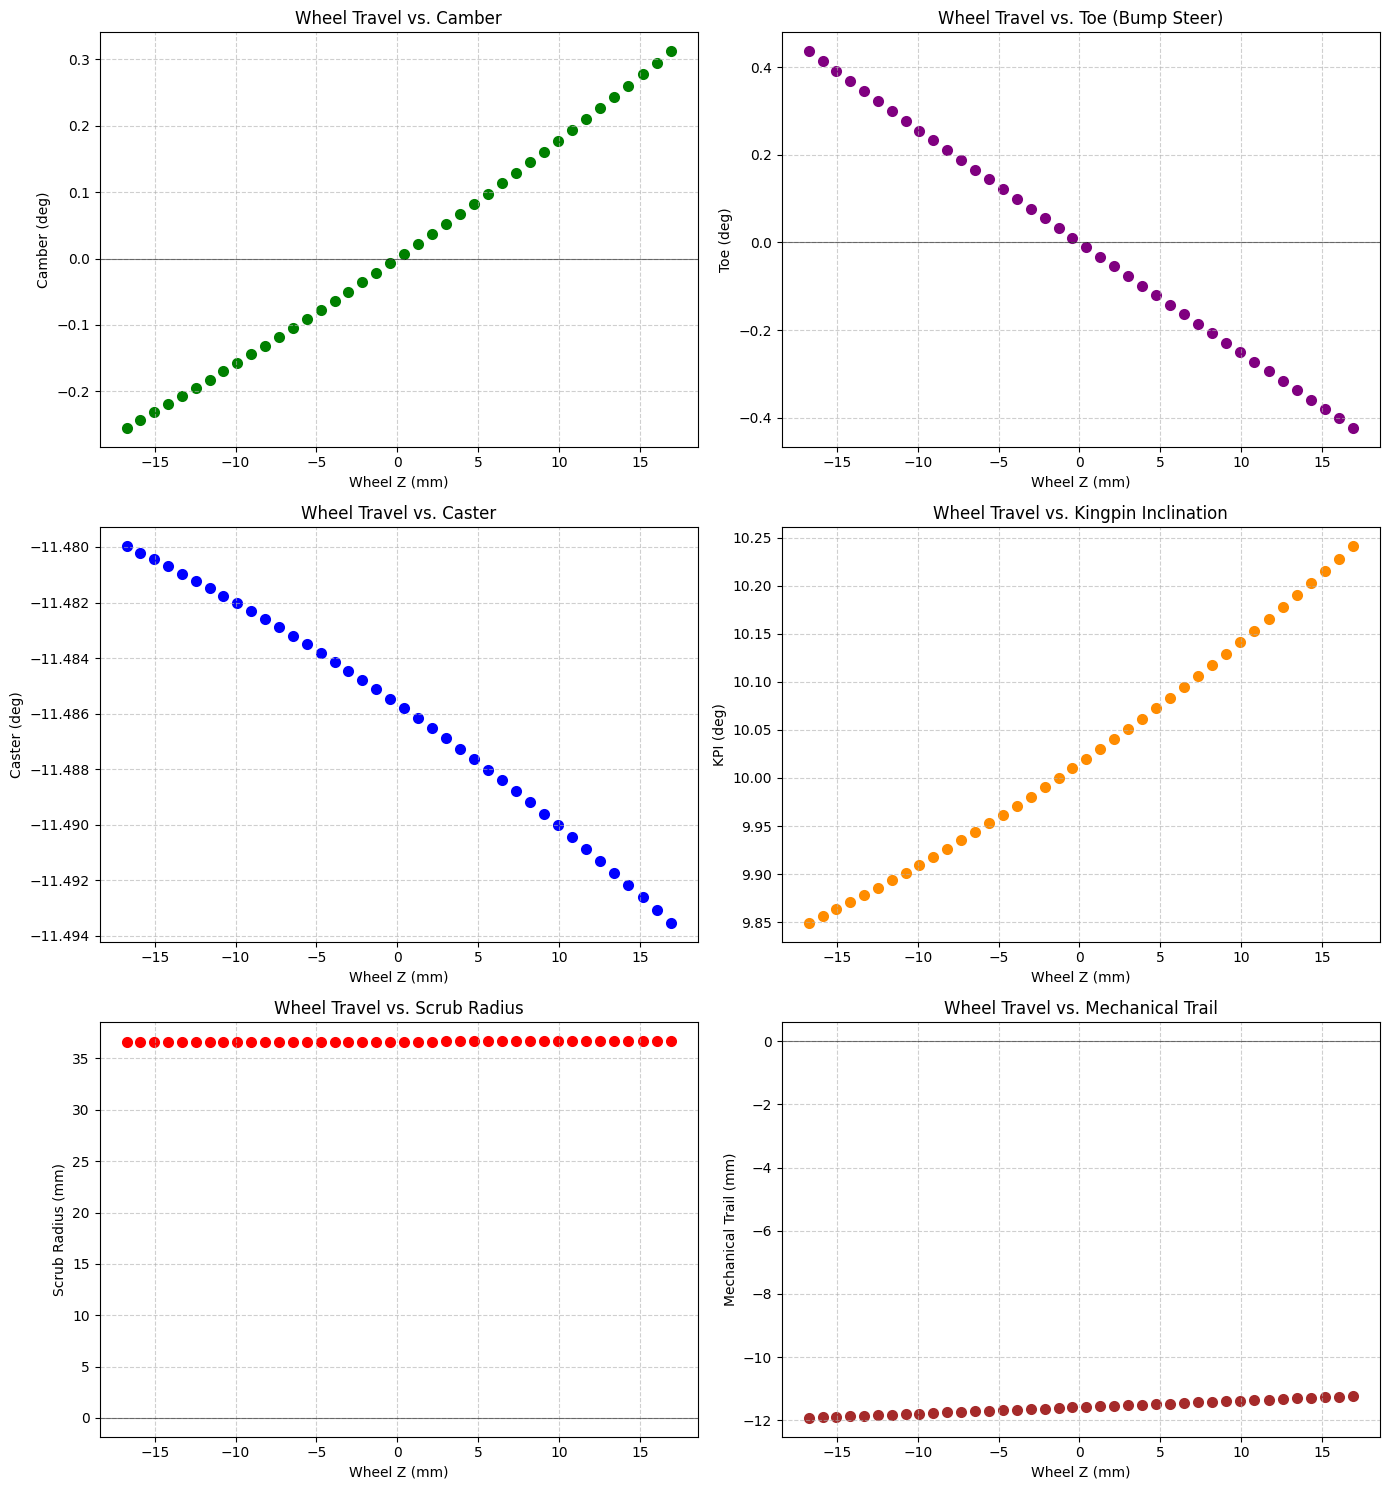

In [5]:
'''SWEEP TEST BLOCK - REAR'''

# 1. Setup Parameters
corner_name = "rear_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Define the Range of Motion
thetas = jnp.radians(jnp.linspace(-5.0, 5.0, 40)) 
# thetas = 0.0
fixed_steer = 0.0

# 3. Initialize storage for results
travel_mm = []
caster_deg = []
scrub_mm = []
camber_deg = []
toe_deg = []
kpi_deg = []    
mech_trail_mm = [] 
contact_point = []

# 4. Run the Sweep Loop
for t in thetas:
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Store the values (converting to readable units)
    travel_mm.append(metrics["wheel_z"] * 1000)
    caster_deg.append(jnp.degrees(metrics["caster"]))
    scrub_mm.append(metrics["scrub_radius"] * 1000)
    camber_deg.append(jnp.degrees(metrics["camber"]))
    toe_deg.append(jnp.degrees(metrics["toe"]))
    kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
    mech_trail_mm.append(metrics["mechanical_trail"] * 1000)
    contact_point.append(metrics["contact_point"][2]*1000)

    # print(metrics["contact_point"][2])

# 5. Plotting (Expanded to 3x2 Grid)
plt.figure(figsize=(14, 15))

# Plot 1: Camber Curve
plt.subplot(3, 2, 1)
plt.scatter(contact_point, camber_deg, color='green', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Camber")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Camber (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Bump Steer (Toe)
plt.subplot(3, 2, 2)
plt.scatter(contact_point, toe_deg, color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Toe (Bump Steer)")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Toe (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Caster
plt.subplot(3, 2, 3)
plt.scatter(contact_point, caster_deg, color='blue', linewidth=2)
plt.title("Wheel Travel vs. Caster")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Caster (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Kingpin Inclination (KPI/SAI)
plt.subplot(3, 2, 4)
plt.scatter(contact_point, kpi_deg, color='darkorange', linewidth=2)
plt.title("Wheel Travel vs. Kingpin Inclination")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("KPI (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 5: Scrub Radius
plt.subplot(3, 2, 5)
plt.scatter(contact_point, scrub_mm, color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Scrub Radius")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Scrub Radius (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 6: Mechanical Trail
plt.subplot(3, 2, 6)
plt.scatter(contact_point, mech_trail_mm, color='brown', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Mechanical Trail")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Mechanical Trail (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

0.19556755


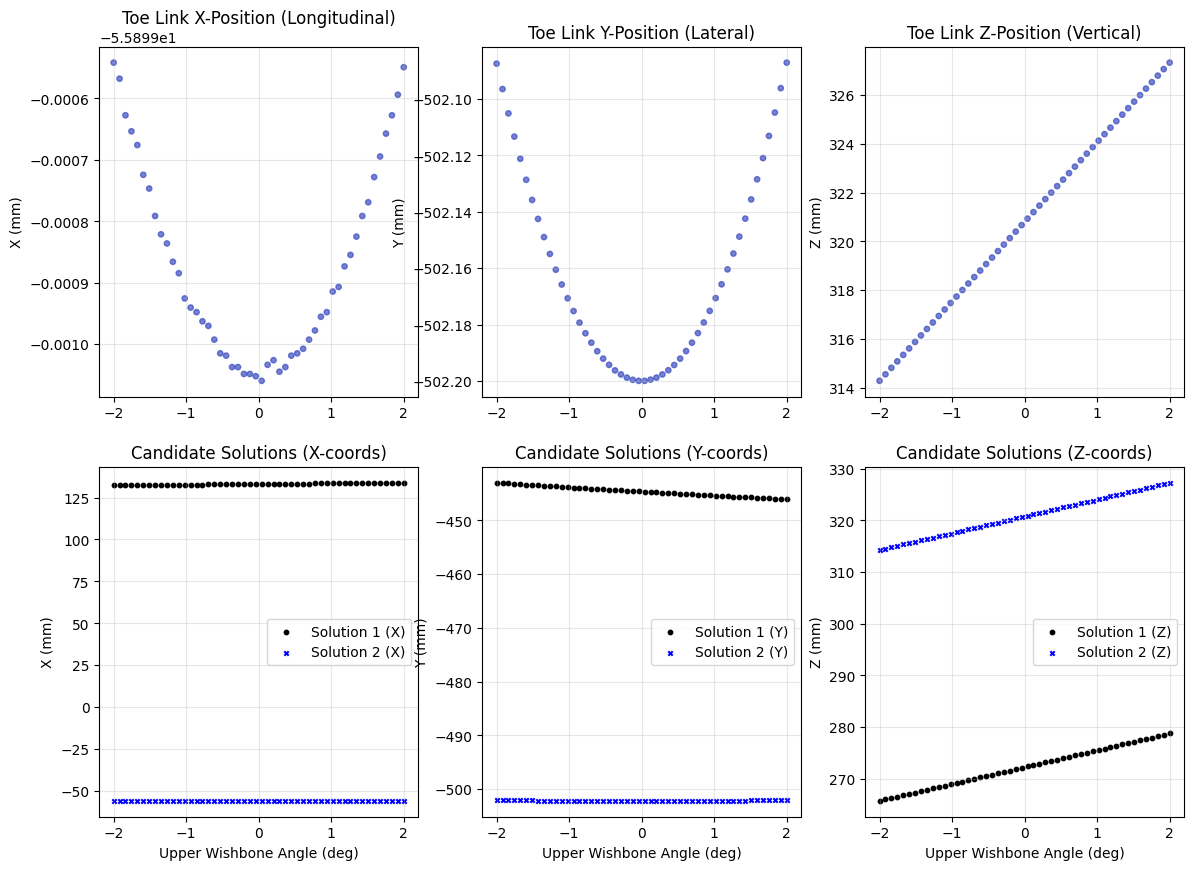

In [10]:
def plot_upper_bj_motion(params, theta_range_deg=(-1.0, 1.0), num_points=50, fixed_steer=0.0):
    """
    Plots X, Y, Z coordinates of the Toe Link and the Solver Solution Boolean (float version).
    """
    # 1. Define the Range of Motion
    thetas_rad = jnp.radians(jnp.linspace(theta_range_deg[0], theta_range_deg[1], num_points))
    
    # 2. Initialize storage
    theta_axis = []
    toe_x, toe_y, toe_z = [], [], []
    sol_bools = []
    determins = []
    tracers = []
    sol1s = []
    sol2s = []

    # 3. Run the Sweep
    for t in thetas_rad:
        # solve_and_measure_corner now returns sol_bool as a 1.0 or 0.0 float
        metrics = solve_and_measure_corner(t, fixed_steer, params)
        
        bj = metrics["toe_link"] 
        deters = metrics["determinant"]
        traces = metrics["trace"]
        sol1 = metrics['sol1']
        sol2 = metrics['sol2']
        
        # Extract the scalar value from the JAX array/tracer
        sb = float(metrics["sol_bool"]) 
        
        theta_axis.append(float(jnp.degrees(t)))
        toe_x.append(float(bj[0]) * 1000) # mm
        toe_y.append(float(bj[1]) * 1000) # mm
        toe_z.append(float(bj[2]) * 1000) # mm
        sol_bools.append(sb)
        determins.append(deters)
        tracers.append(traces)
        sol1s.append(sol1)
        sol2s.append(sol2)
        
    # 4. Plotting (2x2 Grid)
    plt.figure(figsize=(14, 10))
    x_label = "Upper Wishbone Angle (deg)"
    print(params['tie_rod_len'])

    # Plot 1: X Position
    plt.subplot(2, 3, 1)
    # Using scatter with 'c' color-coded by sol_bool to visualize the flip point
    plt.scatter(theta_axis, toe_x, c=sol_bools, cmap='coolwarm', s=15, alpha=0.7)
    plt.title("Toe Link X-Position (Longitudinal)")
    plt.ylabel("X (mm)")
    plt.grid(True, alpha=0.3)

    # Plot 2: Y Position
    plt.subplot(2, 3, 2)
    plt.scatter(theta_axis, toe_y, c=sol_bools, cmap='coolwarm', s=15, alpha=0.7)
    plt.title("Toe Link Y-Position (Lateral)")
    plt.ylabel("Y (mm)")
    plt.grid(True, alpha=0.3)

    # Plot 3: Z Position
    plt.subplot(2, 3, 3)
    plt.scatter(theta_axis, toe_z, c=sol_bools, cmap='coolwarm', s=15, alpha=0.7)
    plt.title("Toe Link Z-Position (Vertical)")
    plt.ylabel("Z (mm)")
    plt.grid(True, alpha=0.3)

    # Plot 4: Solver Choice (Visualized as 0/1)
    # Plot 4: Comparison of both potential geometric solutions (X-coordinate)
    plt.subplot(2, 3, 4)
    
    # Extract the X-coordinate (index 0) for each solution in the lists
    sol1_x = [float(s[0]) * 1000 for s in sol1s]
    sol2_x = [float(s[0]) * 1000 for s in sol2s]
    
    plt.scatter(theta_axis, sol1_x, color='black', s=10, label='Solution 1 (X)')
    plt.scatter(theta_axis, sol2_x, color='blue', s=10, marker='x', label='Solution 2 (X)')
    
    plt.title("Candidate Solutions (X-coords)")
    plt.xlabel(x_label)
    plt.ylabel("X (mm)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 5)
    
    # Extract the Y-coordinate (index 0) for each solution in the lists
    sol1_x = [float(s[1]) * 1000 for s in sol1s]
    sol2_x = [float(s[1]) * 1000 for s in sol2s]
    
    plt.scatter(theta_axis, sol1_x, color='black', s=10, label='Solution 1 (Y)')
    plt.scatter(theta_axis, sol2_x, color='blue', s=10, marker='x', label='Solution 2 (Y)')
    
    plt.title("Candidate Solutions (Y-coords)")
    plt.xlabel(x_label)
    plt.ylabel("Y (mm)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    
    # Extract the Z-coordinate (index 0) for each solution in the lists
    sol1_x = [float(s[2]) * 1000 for s in sol1s]
    sol2_x = [float(s[2]) * 1000 for s in sol2s]
    
    plt.scatter(theta_axis, sol1_x, color='black', s=10, label='Solution 1 (Z)')
    plt.scatter(theta_axis, sol2_x, color='blue', s=10, marker='x', label='Solution 2 (Z)')
    
    plt.title("Candidate Solutions (Z-coords)")
    plt.xlabel(x_label)
    plt.ylabel("Z (mm)")
    plt.legend()
    plt.grid(True, alpha=0.3)

# Example Usage:
corner_name = "rear_right"
params = load_suspension_params("hardpoints.yaml", corner_name)
# params['tie_rod_len'] = params['tie_rod_len'] * 1.05
plot_upper_bj_motion(params, theta_range_deg=(-2.0, 2.0))

In [7]:
'''STATIC VISUALIZER @ THETA + STEER'''

# 1. Setup the parameters (All 4 corners)
params_all = {
    "fr": load_suspension_params("hardpoints.yaml", "front_right"),
    "fl": load_suspension_params("hardpoints.yaml", "front_left"),
    "rr": load_suspension_params("hardpoints.yaml", "rear_right"),
    "rl": load_suspension_params("hardpoints.yaml", "rear_left")
}

# 2. Initialize Visualizer (using FR as base)
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# 3. Build Chassis and 4. Solve States
steer_val = 0.01 # m
thetas = jnp.deg2rad(2.0)
initial_states = {}

for name, p in params_all.items():
    # Add static chassis points with a suffix
    viz.add_chassis_points(p, suffix=name)
    
    # Solve kinematics
    state = solve_and_measure_corner(thetas, steer_val, p)
    initial_states[name] = state
    
    # Update the rack position immediately after creating it
    viz.update_rack_displacement(f"rack_mesh_{name}", p['rack_origin'], steer_val)

    # Setup ICs and ISA
    # viz.setup_instant_center(state["instant_roll_center"], state["contact_point"], f"ic_{name}")
    # viz.setup_isa_axis(state["isa_q"], state["isa_s"], f"isa_{name}")

# 5. Setup the moving parts for all 4 corners
for name, p in params_all.items():
    state = initial_states[name]
    
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # A-Arms
    viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")

    # Hardpoints
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")

    # Upright
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")

    steered_rack_pos = p["rack_origin"] + np.array([0, steer_val, 0])
    viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    
    # Wheel
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{name}")
    # print(state["wheel_center"])

# 6. Preview the full car
viz.plotter.reset_camera()
viz.plotter.camera_position = [(5, -5, 2), (1, 0, 0.5), (0, 0, 1)]
viz.plotter.show()

Widget(value='<iframe src="http://localhost:62038/index.html?ui=P_0x145fbd1d0_0&reconnect=auto" class="pyvista…

In [13]:
'''STATIC VISUALIZER @ CHASSIS POSE + STEER'''

# --- INPUTS ---
chassis_pose = {
    'xyz': [0.0, 0.0, 0.0],
    'roll': jnp.deg2rad(2.0),  
    'pitch': jnp.deg2rad(0.0)
}
steer_val = 0.0  # rack displacement in meters

# --- PROCESSING ---
initial_states = {}
world_params_all = {}

for name, local_p in params_all.items():
    # Only steer front wheels
    current_steer = steer_val if "f" in name else 0.0
    
    world_p = get_world_params(local_p, chassis_pose['xyz'], chassis_pose['roll'], chassis_pose['pitch'])
    
    try:
        # Solve for the compression angle relative to world ground
        ground_theta = solve_theta_for_ground(current_steer, world_p)
        state_jax = solve_and_measure_corner(ground_theta, current_steer, world_p)
        
        # Convert to numpy and validate
        state_np = {k: np.array(v) for k, v in state_jax.items()}
        
        # Guard against zero-length axle vectors for the wheel disc visualizer
        if np.linalg.norm(state_np["axle_dir"]) < 1e-6:
            state_np["axle_dir"] = np.array([0.0, 1.0, 0.0])

        initial_states[name] = state_np
        world_params_all[name] = world_p
        
    except Exception as e:
        print(f"Solver failed for corner {name}: {e}")

# --- VISUALIZATION ---
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# 1. Draw the Chassis Skeleton
viz.add_chassis_skeleton(world_params_all)

# 2. Draw the individual corners
for name, p_world in world_params_all.items():
    state = initial_states[name]
    p_local = params_all[name] # Get local for constants like side_sign
    
    # Logic for Front-Only Steering
    current_steer = steer_val if "f" in name else 0.0
    
    # Component colors
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # --- Moving Suspension Geometry ---
    viz.setup_a_arms(p_world["u_front"], p_world["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p_world["l_front"], p_world["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")
    
    # --- Hardpoint Spheres ---
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")
    # Optional: Chassis side hardpoints
    viz.setup_hardpoints(p_world["u_front"], f"UF_{name}")
    viz.setup_hardpoints(p_world["u_rear"], f"UR_{name}")
    viz.setup_hardpoints(p_world["l_front"], f"LF_{name}")
    viz.setup_hardpoints(p_world["l_rear"], f"LR_{name}")

    # --- Steering & Wheels ---
    # Apply sign for left/right side steering direction
    actual_rack_travel = current_steer * p_local["side_sign"]
    steered_rack_pos = p_world["rack_origin"] + np.array([0, actual_rack_travel, 0])
    
    viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2, f"wheel_{name}")

# Camera framing
viz.plotter.reset_camera()
viz.plotter.camera_position = [(4, -4, 2), (0, 0, 0.4), (0, 0, 1)]
viz.plotter.show()

Widget(value='<iframe src="http://localhost:62038/index.html?ui=P_0x14cae16d0_4&reconnect=auto" class="pyvista…

In [22]:
'''ANIMATION BLOCK: FULL CHASSIS + SUSPENSION DYNAMICS'''

# 1. Setup the Scene
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# Initialize Chassis Skeleton (Static start)
viz.add_chassis_skeleton(world_params_all)

# Initialize all corner meshes
for name, p_local in params_all.items():
    state = initial_states[name]
    p_world = world_params_all[name]
    
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # Moving Suspension
    viz.setup_a_arms(p_world["u_front"], p_world["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p_world["l_front"], p_world["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")
    
    # Hardpoints (Upright)
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")
    
    # Hardpoints (Chassis-side)
    viz.setup_hardpoints(p_world["u_front"], f"UF_{name}")
    viz.setup_hardpoints(p_world["u_rear"], f"UR_{name}")
    viz.setup_hardpoints(p_world["l_front"], f"LF_{name}")
    viz.setup_hardpoints(p_world["l_rear"], f"LR_{name}")

    # Steering & Wheels
    viz.setup_tie_rod(p_world["rack_origin"], state["toe_link"], f"tie_rod_{name}")
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2, f"wheel_{name}")

# 2. Define Animation Parameters
frames = 10
t_space = jnp.linspace(0, 2 * jnp.pi, frames)

z_sweep = 0.03 * jnp.sin(t_space) # 30mm heave
roll_sweep = jnp.deg2rad(3.0) * jnp.sin(t_space) # 3 deg roll
pitch_sweep = jnp.deg2rad(2.0) * jnp.sin(t_space)
# steer_sweep_range = 0.012 * jnp.sin(t_space) # 12mm rack travel


# 3. Run the Animation Loop
filename = "pitch.mp4"

# --- CAMERA SETUP ---
# Format: [(x, y, z) camera, (x, y, z) target, (x, y, z) up-vector]

# Isometric/Three-Quarter View (Good for overall motion)
# viz.plotter.camera_position = [(5, 0.0, 1.0), (0.0, 0.0, 0.3), (0, 0, 1)]

# Side Profile (Good for visualizing anti-squat/dive and wheelbase)
viz.plotter.camera_position = [(.8, -4, 1.0), (.8, 0, 0.3), (0, 0, 1)]

# Front View (Best for Camber and Roll center visualization)
# viz.plotter.camera_position = [(4, 0, 1.0), (0, 0, 0.3), (0, 0, 1)]

viz.plotter.open_movie(filename)

for i in range(frames):
    # 1. Define current chassis pose for this frame
    curr_pose_xyz = [0, 0, 0]
    # curr_roll = roll_sweep[i]
    curr_roll = 0.0
    # curr_pitch = 0.0 # You can add a pitch sweep here too
    curr_pitch = pitch_sweep[i]
    steer_sweep = 0.0
    # steer_sweep = steer_sweep_range[i]
    
    # 2. Update World Parameters for ALL corners simultaneously
    # This is required for the skeleton to know where all 4 corners are
    current_world_params = {}
    for name, p_local in params_all.items():
        current_world_params[name] = get_world_params(p_local, curr_pose_xyz, curr_roll, curr_pitch)

    # 3. UPDATE CHASSIS SKELETON
    # This draws the lines connecting the wishbone mounts across the car
    viz.update_chassis_skeleton(current_world_params)
    
    # 4. Update individual corners
    for name, p_local in params_all.items():
        p_world = current_world_params[name]
        
        # Now active_steer is a single number, not an array
        active_steer = steer_sweep if "f" in name else 0.0
        
        # This will now work without dimension errors
        ground_theta = solve_theta_for_ground(active_steer, p_world)
        state = solve_and_measure_corner(ground_theta, active_steer, p_world)
        
        # Update Moving Suspension Links
        viz.update_wishbone(f"u_arm_{name}", p_world["u_front"], p_world["u_rear"], state["upper_bj"])
        viz.update_wishbone(f"l_arm_{name}", p_world["l_front"], p_world["l_rear"], state["lower_bj"])
        
        # Update Chassis-Side Hardpoint Spheres
        # These are the points the skeleton connects to
        viz.update_hardpoint(f"UF_{name}", p_world["u_front"])
        viz.update_hardpoint(f"UR_{name}", p_world["u_rear"])
        viz.update_hardpoint(f"LF_{name}", p_world["l_front"])
        viz.update_hardpoint(f"LR_{name}", p_world["l_rear"])
        
        # Update Upright Hardpoints & Wheels
        viz.update_hardpoint(f"UBJ_{name}", state["upper_bj"])
        viz.update_upright(f"upright_{name}", state["upper_bj"], state["lower_bj"], state["toe_link"])
        viz.update_wheel(f"wheel_{name}", state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2)

        actual_rack_travel = active_steer * p_local["side_sign"]
        steered_rack_pos = p_world["rack_origin"] + jnp.array([0, actual_rack_travel, 0])
        
        # Update the cylinder mesh
        viz.update_tie_rod(f"tie_rod_{name}", steered_rack_pos, state["toe_link"])
        
    viz.plotter.write_frame()

viz.plotter.close()

/opt/homebrew/Cellar/python@3.11/3.11.15/Frameworks/Python.framework/Versions/3.11/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


In [25]:
'''ANIMATION BLOCK: FULL CHASSIS + SUSPENSION DYNAMICS'''

# 0. Configuration & Wheelbase calculation
# Assuming u_front[0] of the front-right corner represents the wheelbase length
wheelbase = 1.525

# 1. Setup the Scene
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# Initialize Chassis Skeleton (Static start)
viz.add_chassis_skeleton(world_params_all)

# Initialize all corner meshes
for name, p_local in params_all.items():
    state = initial_states[name]
    p_world = world_params_all[name]
    
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # Moving Suspension
    viz.setup_a_arms(p_world["u_front"], p_world["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p_world["l_front"], p_world["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")
    
    # Hardpoints (Upright)
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")
    
    # Hardpoints (Chassis-side)
    viz.setup_hardpoints(p_world["u_front"], f"UF_{name}")
    viz.setup_hardpoints(p_world["u_rear"], f"UR_{name}")
    viz.setup_hardpoints(p_world["l_front"], f"LF_{name}")
    viz.setup_hardpoints(p_world["l_rear"], f"LR_{name}")

    # Steering & Wheels
    viz.setup_tie_rod(p_world["rack_origin"], state["toe_link"], f"tie_rod_{name}")
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2, f"wheel_{name}")

# 2. Define Animation Parameters
frames = 60
t_space = jnp.linspace(0, 2 * jnp.pi, frames)

z_sweep = 0.02 * jnp.sin(t_space)             # 20mm heave
# roll_sweep = jnp.deg2rad(2.0) * jnp.sin(t_space) # 2 deg roll
pitch_sweep = jnp.deg2rad(3.0) * jnp.sin(t_space) # 3 deg pitch
roll_sweep = 0.0

# 3. Run the Animation Loop
filename = "pitch.mp4"

# Set Side Profile Camera
viz.plotter.camera_position = [(wheelbase/2, -4.5, 1.0), (wheelbase/2, 0, 0.3), (0, 0, 1)]

viz.plotter.open_movie(filename)

for i in range(frames):
    # --- STEP A: CALCULATE CHASSIS POSE ---
    curr_pitch = pitch_sweep[i]
    # curr_roll = roll_sweep[i]
    curr_roll = 0.0
    
    # PIVOT CORRECTION:
    # Since origin is at rear axle, rotate about middle by adding z offset
    z_correction = (wheelbase / 2.0) * jnp.sin(curr_pitch)
    curr_pose_xyz = [0, 0, z_sweep[i] + z_correction]
    
    # --- STEP B: UPDATE WORLD COORDINATES ---
    current_world_params = {}
    for name, p_local in params_all.items():
        current_world_params[name] = get_world_params(p_local, curr_pose_xyz, curr_roll, curr_pitch)

    # Update the Pink Skeleton lines
    viz.update_chassis_skeleton(current_world_params)
    
    # --- STEP C: SOLVE & UPDATE INDIVIDUAL CORNERS ---
    for name, p_local in params_all.items():
        p_world = current_world_params[name]
        
        # Steering (static for this pitch/roll test, or add sweep[i] if desired)
        active_steer = 0.0 
        
        # Solve kinematics for ground contact
        ground_theta = solve_theta_for_ground(active_steer, p_world)
        state = solve_and_measure_corner(ground_theta, active_steer, p_world)
        
        # 1. Update Wishbone Meshes
        viz.update_wishbone(f"u_arm_{name}", p_world["u_front"], p_world["u_rear"], state["upper_bj"])
        viz.update_wishbone(f"l_arm_{name}", p_world["l_front"], p_world["l_rear"], state["lower_bj"])
        
        # 2. Update Chassis Mount Points (Spheres)
        viz.update_hardpoint(f"UF_{name}", p_world["u_front"])
        viz.update_hardpoint(f"UR_{name}", p_world["u_rear"])
        viz.update_hardpoint(f"LF_{name}", p_world["l_front"])
        viz.update_hardpoint(f"LR_{name}", p_world["l_rear"])
        
        # 3. Update Upright & Outboard Hardpoints
        viz.update_hardpoint(f"UBJ_{name}", state["upper_bj"])
        viz.update_hardpoint(f"TOE_{name}", state["toe_link"])
        viz.update_upright(f"upright_{name}", state["upper_bj"], state["lower_bj"], state["toe_link"])
        
        # 4. Update Tie Rods
        actual_rack_travel = active_steer * p_local["side_sign"]
        steered_rack_pos = p_world["rack_origin"] + jnp.array([0, actual_rack_travel, 0])
        viz.update_tie_rod(f"tie_rod_{name}", steered_rack_pos, state["toe_link"])

        # 5. Update Wheels
        viz.update_wheel(f"wheel_{name}", state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2)
        
    viz.plotter.write_frame()

viz.plotter.close()

/opt/homebrew/Cellar/python@3.11/3.11.15/Frameworks/Python.framework/Versions/3.11/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(
